# Task 1 — Sales Data Cleaning & Analysis

**InternSpark Business Analytics Internship | Sales Data Analysis**

### Business Objective
Clean the sales dataset, derive core sales KPIs, identify data-quality issues, and generate actionable insights on sales by product, market, time, and order status.

**Dataset source:** Kaggle — *Sample Sales Data* (public dataset).  
**Important:** This is a representative/public dataset for the internship task and is **not presented as Alfido Tech internal data**.

---

## Executive Summary

The dataset contains **2,823 order-line records and 307 unique orders** covering January 2003 to May 2005, with total recorded sales of **$10.03M** and an average order value of **$32,679.57**.

### Key findings
1. **Classic Cars is the core revenue driver**, contributing **39.07%** of total sales. Classic Cars and Vintage Cars together contribute **58.04%**.
2. **High-growth opportunities exist beyond the core category.** From 2003 to 2004, Planes grew **84.63%**, Motorcycles **51.13%**, and Vintage Cars **40.01%**, while Classic Cars grew **18.69%**.
3. **Sales show strong seasonality.** Average November sales were approximately **$1.06M**, about **4.75×** the average April sales of approximately **$223K**. November 2004 was the highest observed month at **$1.09M**.
4. **Revenue is geographically concentrated.** The USA contributed **36.16%** of sales; the USA, Spain and France together contributed **59.35%**.
5. **Most orders are shipped, but exceptions matter.** 93.16% of unique orders were shipped. Non-shipped statuses represent **7.39% of sales value**, including **$194K of cancelled sales value**.

### Recommended actions
- Protect availability and performance of Classic Cars.
- Selectively invest in high-growth categories such as Planes and Motorcycles.
- Plan inventory, sales capacity and fulfillment ahead of the October–November peak.
- Strengthen major markets while testing targeted growth in lower-contributing markets.
- Investigate cancellations, holds and disputes, prioritizing high-value exceptions.

### KPI framework
Track product-line sales/share, product-line YoY growth, Q4 sales and stockouts, country sales growth, cancellation rate, dispute/on-hold rate, and exception-order value.

> **Data note:** 2005 contains only January–May, so it is not treated as a complete year. Deal Size is an order-line attribute; 277 of 307 orders contain multiple deal sizes, so deal-size order shares are not used for order-level conclusions.


## 1. Dataset Loading & Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

candidate_paths = [
    Path("sales_data_sample.csv"),
    Path("/content/sales_data_sample.csv"),
    Path("/content/drive/MyDrive/internship_Internspark/Sales_Project/sales_data_sample.csv")
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "sales_data_sample.csv was not found. Upload the CSV to the Colab session "
        "or update DATA_PATH to its location in Google Drive."
    )

df = pd.read_csv(DATA_PATH, encoding="latin1")

print(f"Dataset loaded successfully from: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Dataset loaded successfully from: sales_data_sample.csv
Rows: 2,823
Columns: 25


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


## 2. Data Quality Assessment

In [2]:
print("Data types:")
display(df.dtypes.to_frame("Data Type"))

missing_summary = (
    df.isna().sum()
      .to_frame("Missing Values")
      .assign(Missing_Percentage=lambda x: x["Missing Values"] / len(df) * 100)
      .query("`Missing Values` > 0")
      .sort_values("Missing Values", ascending=False)
)

print("Missing-value summary:")
display(missing_summary)

duplicate_count = int(df.duplicated().sum())
print(f"Exact duplicate rows: {duplicate_count}")

categorical_columns = ["STATUS", "PRODUCTLINE", "COUNTRY", "TERRITORY", "DEALSIZE"]
for col in categorical_columns:
    values = sorted(df[col].dropna().astype(str).str.strip().unique().tolist())
    print(f"{col}: {values}")


Data types:


,Data Type
ORDERNUMBER,int64
QUANTITYORDERED,int64
PRICEEACH,float64
ORDERLINENUMBER,int64
SALES,float64
ORDERDATE,object
STATUS,object
QTR_ID,int64
MONTH_ID,int64
YEAR_ID,int64


Missing-value summary:


,Missing Values,Missing_Percentage
ADDRESSLINE2,2521,89.302161
STATE,1486,52.639036
TERRITORY,1074,38.044633
POSTALCODE,76,2.692171


Exact duplicate rows: 0
STATUS: ['Cancelled', 'Disputed', 'In Process', 'On Hold', 'Resolved', 'Shipped']
PRODUCTLINE: ['Classic Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains', 'Trucks and Buses', 'Vintage Cars']
COUNTRY: ['Australia', 'Austria', 'Belgium', 'Canada', 'Denmark', 'Finland', 'France', 'Germany', 'Ireland', 'Italy', 'Japan', 'Norway', 'Philippines', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'UK', 'USA']
TERRITORY: ['APAC', 'EMEA', 'Japan']
DEALSIZE: ['Large', 'Medium', 'Small']


## 3. Data Cleaning

In [3]:
df_clean = df.copy()

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

df_clean["ORDERDATE"] = pd.to_datetime(df_clean["ORDERDATE"], errors="coerce")

for col in ["ADDRESSLINE2", "STATE", "POSTALCODE"]:
    df_clean[col] = df_clean[col].fillna("Not Provided")

print("Rows/columns after cleaning:", df_clean.shape)
print("Invalid/missing parsed dates:", int(df_clean["ORDERDATE"].isna().sum()))

final_missing = (
    df_clean.isna().sum()
    .to_frame("Missing Values After Cleaning")
    .query("`Missing Values After Cleaning` > 0")
)

display(final_missing)


Rows/columns after cleaning: (2823, 25)
Invalid/missing parsed dates: 0


,Missing Values After Cleaning
TERRITORY,1074


### Data-cleaning decisions

- `ORDERDATE` was converted to datetime.
- Missing `ADDRESSLINE2`, `STATE`, and `POSTALCODE` values were labeled **Not Provided** rather than dropping rows.
- `TERRITORY` remains missing where the source does not provide a defensible business-rule imputation.
- No exact duplicate rows were found.
- No obvious spelling/spacing inconsistencies were identified in the main categorical fields after trimming whitespace.


## 4. Core Sales KPIs

In [4]:
total_sales = df_clean["SALES"].sum()
total_orders = df_clean["ORDERNUMBER"].nunique()
average_order_value = total_sales / total_orders

kpi_table = pd.DataFrame({
    "KPI": ["Total Sales", "Unique Orders", "Average Order Value"],
    "Value": [f"${total_sales:,.2f}", f"{total_orders:,}", f"${average_order_value:,.2f}"]
})
display(kpi_table)


,KPI,Value
0,Total Sales,"$10,032,628.85"
1,Unique Orders,307
2,Average Order Value,"$32,679.57"


## 5. Product Performance

In [5]:
productline_sales = (
    df_clean.groupby("PRODUCTLINE")["SALES"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="Total Sales")
)

productline_sales["Sales Contribution %"] = (
    productline_sales["Total Sales"] / total_sales * 100
)

display(productline_sales)

top_products = (
    df_clean.groupby(["PRODUCTCODE", "PRODUCTLINE"])["SALES"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="Total Sales")
)

print("Top 10 individual products by sales:")
display(top_products.head(10))


,PRODUCTLINE,Total Sales,Sales Contribution %
0,Classic Cars,3919615.66,39.068680
1,Vintage Cars,1903150.84,18.969613
2,Motorcycles,1166388.34,11.625949
3,Trucks and Buses,1127789.84,11.241220
4,Planes,975003.57,9.718326
5,Ships,714437.13,7.121136
6,Trains,226243.47,2.255077


Top 10 individual products by sales:


,PRODUCTCODE,PRODUCTLINE,Total Sales
0,S18_3232,Classic Cars,288245.42
1,S10_1949,Classic Cars,191073.03
2,S10_4698,Motorcycles,170401.07
3,S12_1108,Classic Cars,168585.32
4,S18_2238,Classic Cars,154623.95
5,S12_3891,Classic Cars,145332.04
6,S24_3856,Classic Cars,140626.90
7,S12_2823,Motorcycles,140006.16
8,S18_1662,Planes,139421.97
9,S12_1099,Classic Cars,137177.01


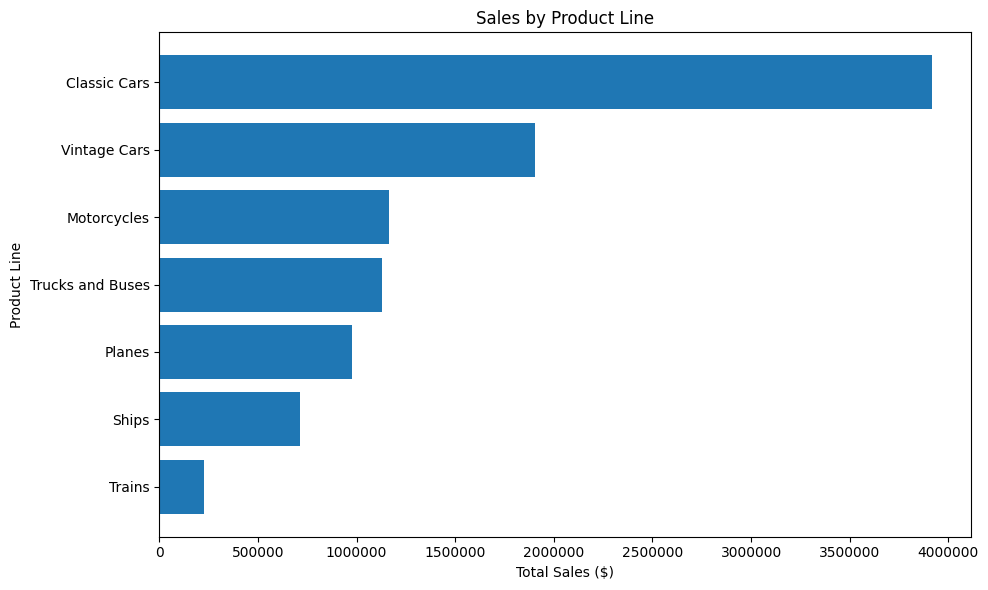

In [6]:
plt.figure(figsize=(10, 6))
plot_df = productline_sales.sort_values("Total Sales", ascending=True)
plt.barh(plot_df["PRODUCTLINE"], plot_df["Total Sales"])
plt.title("Sales by Product Line")
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Line")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


## 6. Monthly Sales Trend & Seasonality

In [7]:
monthly_sales = (
    df_clean.set_index("ORDERDATE")["SALES"]
    .resample("MS")
    .sum()
    .reset_index(name="Total Sales")
)

highest_month = monthly_sales.loc[monthly_sales["Total Sales"].idxmax()]
lowest_month = monthly_sales.loc[monthly_sales["Total Sales"].idxmin()]

calendar_month_sales = (
    monthly_sales.assign(Calendar_Month=monthly_sales["ORDERDATE"].dt.month)
    .groupby("Calendar_Month")["Total Sales"]
    .mean()
    .reset_index(name="Average Monthly Sales")
)

display(monthly_sales)
print("Highest observed month:")
display(highest_month.to_frame().T)
print("Lowest observed month:")
display(lowest_month.to_frame().T)
print("Average sales by calendar month:")
display(calendar_month_sales)


,ORDERDATE,Total Sales
0,2003-01-01,129753.60
1,2003-02-01,140836.19
2,2003-03-01,174504.90
3,2003-04-01,201609.55
4,2003-05-01,192673.11
5,2003-06-01,168082.56
6,2003-07-01,187731.88
7,2003-08-01,197809.30
8,2003-09-01,263973.36
9,2003-10-01,568290.97


Highest observed month:


,ORDERDATE,Total Sales
22,2004-11-01 00:00:00,1089048.01


Lowest observed month:


,ORDERDATE,Total Sales
0,2003-01-01 00:00:00,129753.6


Average sales by calendar month:


,Calendar_Month,Average Monthly Sales
0,1,2.619581e+05
1,2,2.701473e+05
2,3,2.515005e+05
3,4,2.231303e+05
4,5,3.079909e+05
5,6,2.273784e+05
6,7,2.574380e+05
7,8,3.296553e+05
8,9,2.923621e+05
9,10,5.606076e+05


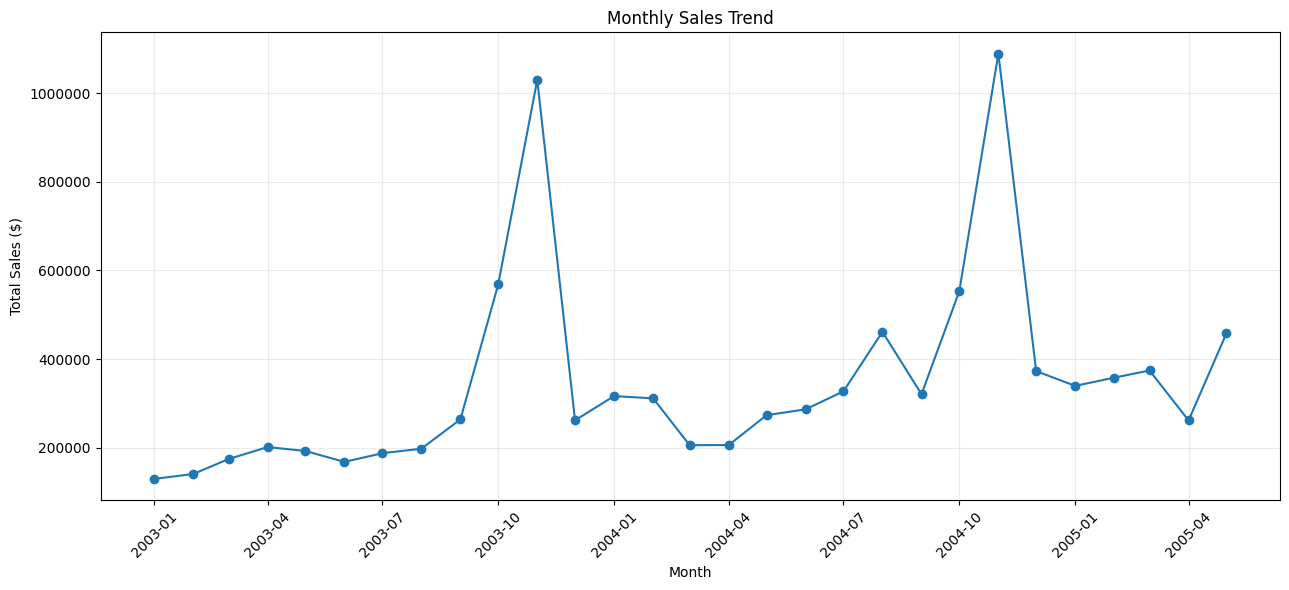

In [8]:
plt.figure(figsize=(13, 6))
plt.plot(monthly_sales["ORDERDATE"], monthly_sales["Total Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 7. Geographic Performance

In [9]:
country_sales = (
    df_clean.groupby("COUNTRY")["SALES"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="Total Sales")
)

country_sales["Sales Contribution %"] = (
    country_sales["Total Sales"] / total_sales * 100
)

country_product_sales = (
    df_clean.groupby(["COUNTRY", "PRODUCTLINE"])["SALES"]
    .sum()
    .reset_index()
    .sort_values(["COUNTRY", "SALES"], ascending=[True, False])
)

display(country_sales)
print("Country × Product Line sample:")
display(country_product_sales.head(20))


,COUNTRY,Total Sales,Sales Contribution %
0,USA,3627982.83,36.161836
1,Spain,1215686.92,12.117332
2,France,1110916.52,11.073035
3,Australia,630623.10,6.285721
4,UK,478880.46,4.773230
5,Italy,374674.31,3.734558
6,Finland,329581.91,3.285100
7,Norway,307463.70,3.064637
8,Singapore,288488.41,2.875502
9,Denmark,245637.15,2.448383


Country × Product Line sample:


,COUNTRY,PRODUCTLINE,SALES
0,Australia,Classic Cars,193085.54
6,Australia,Vintage Cars,189555.32
1,Australia,Motorcycles,89968.76
5,Australia,Trucks and Buses,77318.50
2,Australia,Planes,74853.87
3,Australia,Ships,4159.76
4,Australia,Trains,1681.35
7,Austria,Classic Cars,101459.47
12,Austria,Vintage Cars,27197.48
8,Austria,Motorcycles,26047.66


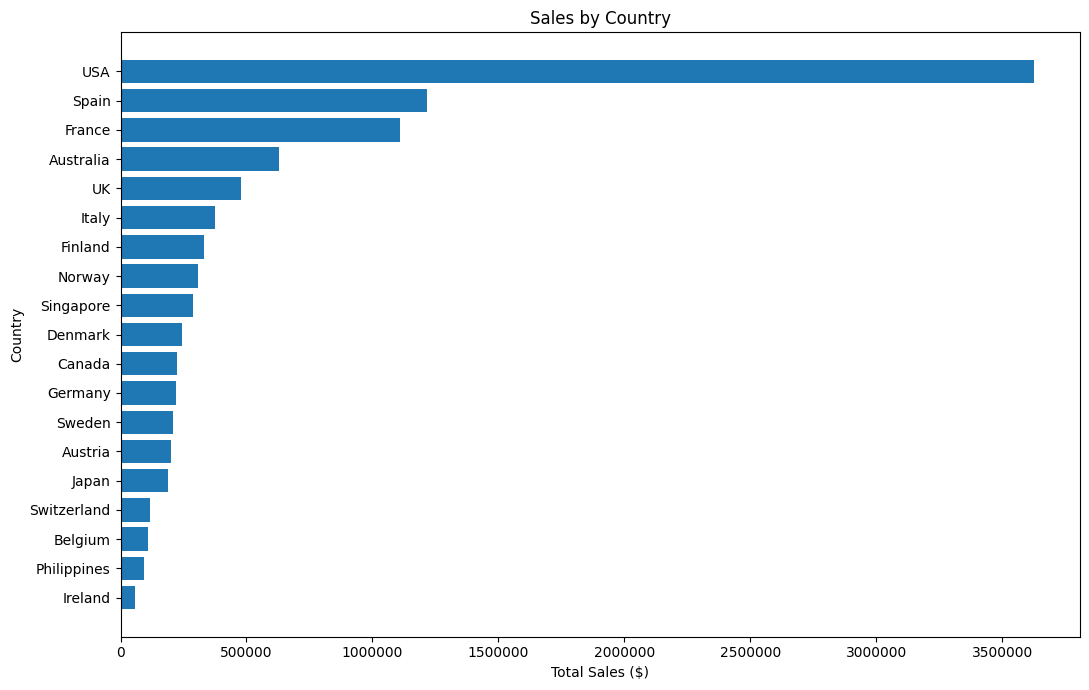

In [10]:
plt.figure(figsize=(11, 7))
plot_df = country_sales.sort_values("Total Sales", ascending=True)
plt.barh(plot_df["COUNTRY"], plot_df["Total Sales"])
plt.title("Sales by Country")
plt.xlabel("Total Sales ($)")
plt.ylabel("Country")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


## 8. Order Status & Operational Health

In [11]:
status_analysis = (
    df_clean.groupby("STATUS")["ORDERNUMBER"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Number of Orders")
)

status_analysis["Order Share %"] = status_analysis["Number of Orders"] / total_orders * 100

status_sales = (
    df_clean.groupby("STATUS")["SALES"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="Total Sales")
)

status_sales["Sales Share %"] = status_sales["Total Sales"] / total_sales * 100

display(status_analysis)
display(status_sales)

non_shipped_sales = total_sales - status_sales.loc[
    status_sales["STATUS"] == "Shipped", "Total Sales"
].iloc[0]

print(f"Sales value in non-shipped statuses: ${non_shipped_sales:,.2f}")
print(f"Share of total sales value: {non_shipped_sales / total_sales * 100:.2f}%")


,STATUS,Number of Orders,Order Share %
0,Shipped,286,93.159609
1,In Process,6,1.954397
2,On Hold,4,1.302932
3,Cancelled,4,1.302932
4,Resolved,4,1.302932
5,Disputed,3,0.977199


,STATUS,Total Sales,Sales Share %
0,Shipped,9291501.08,92.612826
1,Cancelled,194487.48,1.938550
2,On Hold,178979.19,1.783971
3,Resolved,150718.28,1.502281
4,In Process,144729.96,1.442593
5,Disputed,72212.86,0.719780


Sales value in non-shipped statuses: $741,127.77
Share of total sales value: 7.39%


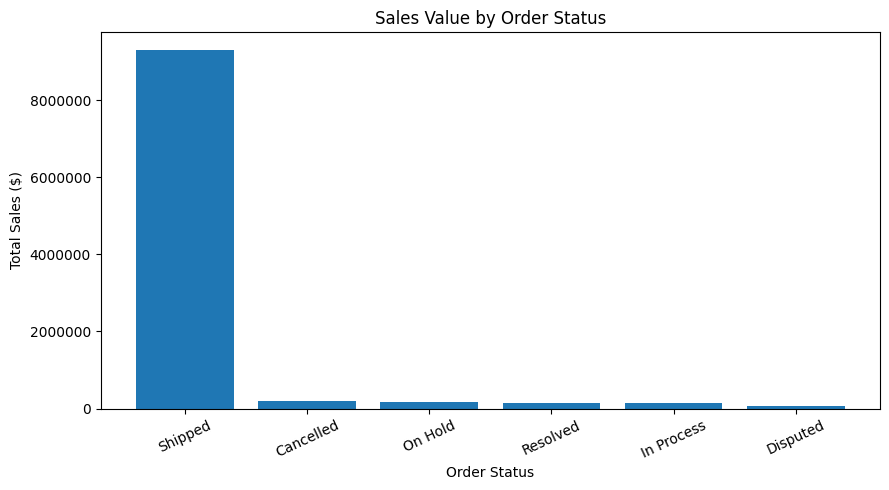

In [12]:
plt.figure(figsize=(9, 5))
plt.bar(status_sales["STATUS"], status_sales["Total Sales"])
plt.title("Sales Value by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## 9. Deal Size Analysis

In [13]:
deal_size_sales = (
    df_clean.groupby("DEALSIZE")["SALES"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="Total Sales")
)

deal_size_sales["Sales Share %"] = deal_size_sales["Total Sales"] / total_sales * 100
display(deal_size_sales)

orders_with_multiple_deal_sizes = (
    df_clean.groupby("ORDERNUMBER")["DEALSIZE"].nunique() > 1
).sum()

print(f"Orders with multiple deal sizes: {orders_with_multiple_deal_sizes} of {total_orders}")


,DEALSIZE,Total Sales,Sales Share %
0,Medium,6087432.24,60.676342
1,Small,2643077.35,26.344813
2,Large,1302119.26,12.978844


Orders with multiple deal sizes: 277 of 307


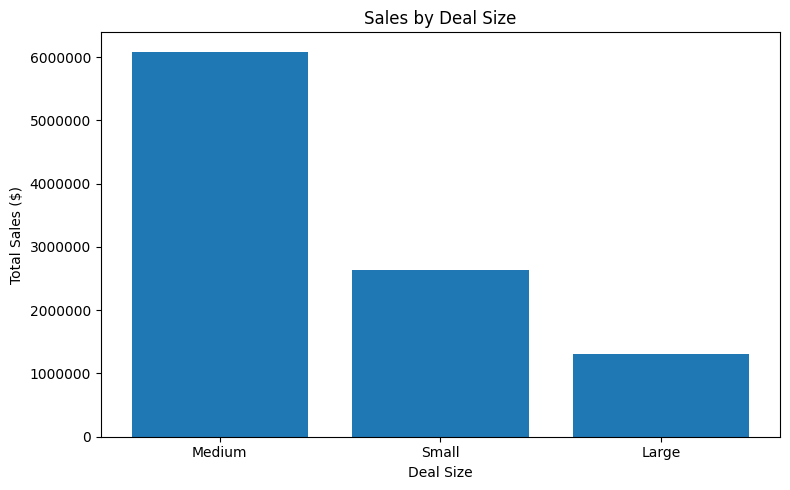

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(deal_size_sales["DEALSIZE"], deal_size_sales["Total Sales"])
plt.title("Sales by Deal Size")
plt.xlabel("Deal Size")
plt.ylabel("Total Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


## 10. Year-over-Year Product Growth

In [15]:
annual_product_sales = (
    df_clean.groupby(["PRODUCTLINE", "YEAR_ID"])["SALES"]
    .sum()
    .unstack(fill_value=0)
)

product_growth = annual_product_sales[[2003, 2004]].copy()
product_growth["Growth %"] = (
    (product_growth[2004] - product_growth[2003])
    / product_growth[2003] * 100
)
product_growth = product_growth.sort_values("Growth %", ascending=False)

display(product_growth)
print("Note: 2005 contains January–May only, so it is excluded from full-year YoY growth.")


YEAR_ID,2003,2004,Growth %
PRODUCTLINE,,,
Planes,272257.60,502671.80,84.630952
Trains,72802.29,116523.85,60.055199
Motorcycles,370895.58,560545.23,51.132896
Vintage Cars,650987.76,911423.77,40.006284
Ships,244821.09,341437.97,39.464280
Trucks and Buses,420429.93,529302.89,25.895625
Classic Cars,1484785.29,1762257.09,18.687672


Note: 2005 contains January–May only, so it is excluded from full-year YoY growth.


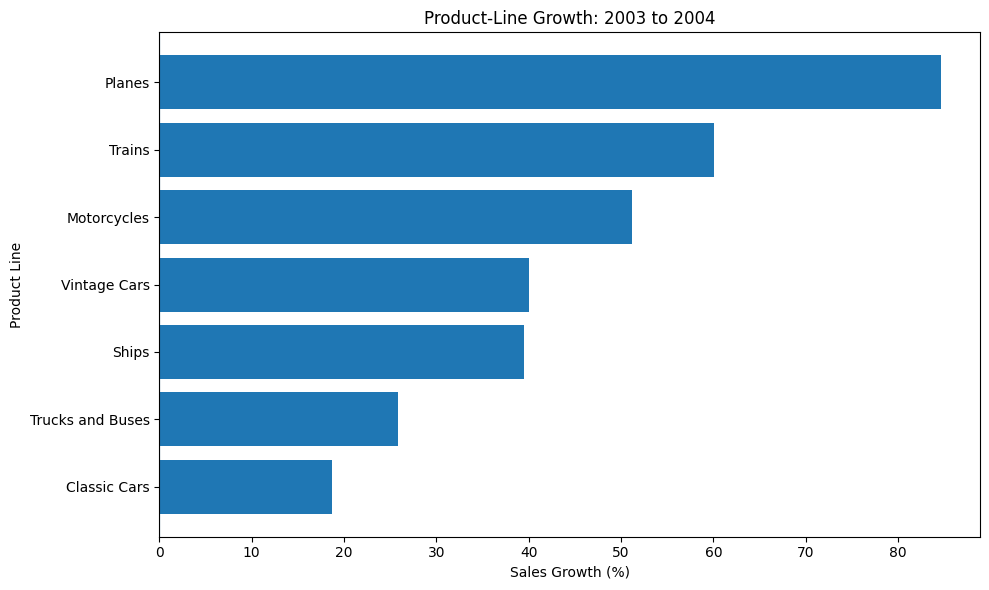

In [16]:
plt.figure(figsize=(10, 6))
plot_df = product_growth.sort_values("Growth %", ascending=True)
plt.barh(plot_df.index, plot_df["Growth %"])
plt.title("Product-Line Growth: 2003 to 2004")
plt.xlabel("Sales Growth (%)")
plt.ylabel("Product Line")
plt.axvline(0, linewidth=0.8)
plt.tight_layout()
plt.show()


## 11. Key Business Insights

### 1. Core revenue concentration
Classic Cars is the largest product line at **39.07% of total sales**. Classic Cars and Vintage Cars together account for **58.04%**, indicating a strong concentration around car-related products.

### 2. Growth beyond the core
Classic Cars grew **18.69%** from 2003 to 2004, but Planes (**84.63%**), Trains (**60.06%**) and Motorcycles (**51.13%**) grew faster.

### 3. Strong seasonal demand
Sales repeatedly spike in October–November. Average November sales are approximately **$1.06M**, versus approximately **$223K** in April. The highest observed month is November 2004 at **$1.09M**.

### 4. Market concentration
The USA contributes **36.16%** of total sales, while the USA, Spain and France together contribute **59.35%**.

### 5. Operational exceptions
93.16% of unique orders are shipped. However, non-shipped statuses represent **7.39% of sales value**. Cancelled orders alone account for approximately **$194K** of sales value.

### 6. Deal-size mix
Medium deal-size line items account for **60.68% of sales**. Because deal size varies within many orders, this is interpreted as a sales-value mix rather than mutually exclusive order shares.


## 12. Prioritized Recommendations

| Priority | Recommendation | Evidence | Action | KPI |
|---|---|---|---|---|
| **1** | Protect the Classic Cars core | 39.07% of sales | Maintain availability, prioritize high-value SKUs, and monitor monthly performance | Classic Cars sales, share, stockouts |
| **2** | Scale high-growth categories selectively | Planes +84.63%; Motorcycles +51.13%; Vintage Cars +40.01% | Increase targeted promotion and inventory testing while monitoring sustainability | Product-line YoY growth and sales share |
| **3** | Prepare for the Q4 demand surge | November average sales ≈ $1.06M | Build inventory and fulfillment capacity before October | Oct–Nov sales, stockouts, fulfillment rate |
| **4** | Strengthen major markets and test diversification | Top 3 = 59.35% | Protect major-market performance and run targeted pilots in selected smaller markets | Country sales growth and contribution |
| **5** | Reduce operational revenue leakage | Non-shipped = 7.39% of sales value; cancellations ≈ $194K | Analyze root causes of cancellations, holds and disputes; prioritize high-value exceptions | Cancellation rate, exception value, dispute/on-hold rate |


## 13. Assumptions & Limitations

- The dataset is analyzed at **order-line level**; `ORDERNUMBER` is used to identify unique orders.
- Average Order Value is calculated as **total sales ÷ unique orders**.
- `TERRITORY` has 1,074 missing values, concentrated in USA and Canada. These values were not artificially imputed.
- `DEALSIZE` is an order-line attribute. **277 of 307 orders contain multiple deal sizes**, so deal-size order shares are not used as mutually exclusive categories.
- 2005 contains only January–May observations and is therefore not compared with 2003/2004 as a complete year.
- The public Kaggle dataset is treated as a representative dataset for this internship task. Recommendations should be validated against current company data before implementation.


## 14. Export Cleaned Dataset

In [17]:
output_path = Path("cleaned_sales_data.csv")
df_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path.resolve()}")
print(f"Rows: {len(df_clean):,} | Columns: {df_clean.shape[1]:,}")


Cleaned dataset saved to: /mnt/data/Task_1_Sales_Data_Analysis/cleaned_sales_data.csv
Rows: 2,823 | Columns: 25
